In [3]:
# ============================================================
# UrbanNest Analytics — European Housing Intelligence
# Notebook 1: Data Cleaning
# Dataset: Italian Rental Listings 2016-2020
# Analyst: Sahil Changotra
# ============================================================


## 🏠 UrbanNest Analytics — Data Cleaning

### Project Overview
End-to-end Python analysis of Italian rental listings dataset
covering 10,000 listings across 31 cities (2016-2020).

### This Notebook Covers
- Step 1: Load and inspect data
- Step 2: Profile data quality
- Step 3: Fix data types
- Step 4: Handle NULLs and missing values
- Step 5: Fix formatting issues
- Step 6: Handle duplicates
- Step 7: Handle outliers
- Step 8: Validate cleaned data
- Step 9: Export clean dataset

In [4]:
# ============================================================
# Import Libraries
# ============================================================



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Display settings

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)


## Step 1: Load and Inspect Data

In [6]:
# ============================================================
# Load Dataset
# ============================================================


df = pd.read_csv('/users/sahilchangotra/documents/urbannest-rental-analytics/data/ha_data_assessement.csv')

In [8]:
# Basic inspection

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("\nColumn Names:")
print(df.columns.tolist())

Shape: (10000, 13)
Rows: 10,000
Columns: 13

Column Names:
['city', 'category', 'country_code', 'created_at', 'price', 'furnished', 'total_size', 'registration_possible', 'washing_machine', 'tv', 'balcony', 'garden', 'terrace']


In [9]:
# First 5 rows of the data

df.head()

,city,category,country_code,created_at,price,furnished,total_size,registration_possible,washing_machine,tv,balcony,garden,terrace
0,Trento,Shared Room,it,2016-03-12 12:31:31,190.00,"""yes""",NaN,NaN,"""no""","""yes""","""no""","""no""","""no"""
1,Milan,Apartment,it,2019-11-14 14:48:10,3200.00,"""yes""","""50""","""yes""","""yes""","""yes""",NaN,"""no""",NaN
2,Milan,Shared Room,it,2019-10-07 10:08:21,660.00,"""yes""","""180""",NaN,"""yes""",NaN,NaN,NaN,NaN
3,Pisa,Shared Room,it,2017-07-05 11:41:57,245.00,"""yes""","""140""","""no""","""yes""","""no""",NaN,"""no""",NaN
4,Bologna,Private Room,it,2017-11-16 08:55:46,500.00,"""yes""","""18""",NaN,"""yes""","""no""",NaN,NaN,NaN


In [10]:
# Data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   city                   9404 non-null   object 
 1   category               9401 non-null   object 
 2   country_code           10000 non-null  object 
 3   created_at             10000 non-null  object 
 4   price                  10000 non-null  float64
 5   furnished              6803 non-null   object 
 6   total_size             5112 non-null   object 
 7   registration_possible  4977 non-null   object 
 8   washing_machine        7929 non-null   object 
 9   tv                     7031 non-null   object 
 10  balcony                2137 non-null   object 
 11  garden                 6729 non-null   object 
 12  terrace                2086 non-null   object 
dtypes: float64(1), object(12)
memory usage: 1015.8+ KB


In [14]:
# Statistical summary

df.describe()

,price
count,10000.00
mean,670.43
std,2430.00
min,0.01
25%,285.00
50%,400.00
75%,650.00
max,190205.00


## Step 2: Profile Data Quality
Profile every column for NULLs, empty strings,
unique values and missing percentage

In [16]:
# ============================================================
# Data Quality Profiling Function
# ============================================================

def profile_dataframe(df):
    profile = []
    for col in df.columns:
        total = len(df)
        null_count = df[col].isnull().sum()
        empty_count = (df[col].astype(str) == '').sum()
        unique_count = df[col].nunique()
        missing_pct = round((null_count + empty_count) * 100 / total, 2)
        dtype = df[col].dtype

        profile.append({
            'column' : col,
            'dtype' : dtype,
            'total_rows' : total,
            'null_count' : null_count,
            'empty_strings' : empty_count,
            'unique_values' : unique_count,
            'missing_pct' : missing_pct
        })

    return pd.DataFrame(profile).sort_values(
        'missing_pct', ascending=False
    )    
profile = profile_dataframe(df)
profile

,column,dtype,total_rows,null_count,empty_strings,unique_values,missing_pct
12,terrace,object,10000,7914,0,4,79.14
10,balcony,object,10000,7863,0,4,78.63
7,registration_possible,object,10000,5023,0,3,50.23
6,total_size,object,10000,4888,0,181,48.88
11,garden,object,10000,3271,0,4,32.71
5,furnished,object,10000,3197,0,3,31.97
9,tv,object,10000,2969,0,3,29.69
8,washing_machine,object,10000,2071,0,3,20.71
1,category,object,10000,599,0,4,5.99
0,city,object,10000,596,0,30,5.96


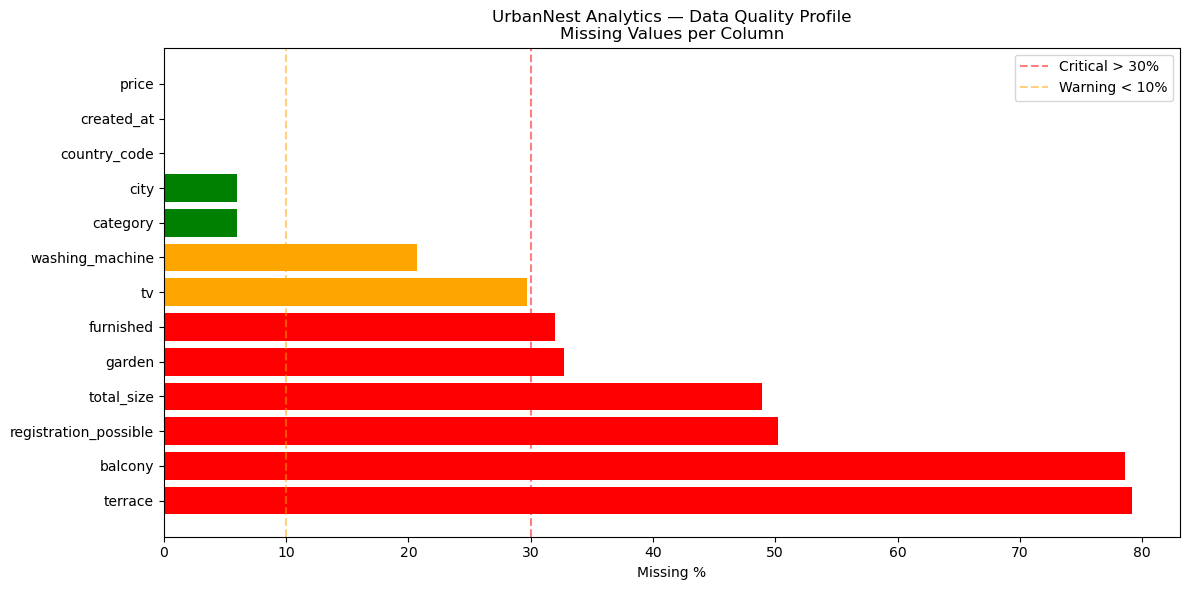

Chart saved to outputs/ ✅


In [21]:
# ============================================================
# Visualise Missing Data
# ============================================================


plt.figure(figsize = (12,6))
colors = ['red' if x > 30
        else 'orange' if x > 10
        else 'green'
        for x in profile['missing_pct']]

plt.barh(profile['column'],
        profile['missing_pct'],
        color = colors)
plt.xlabel('Missing %')
plt.title('UrbanNest Analytics — Data Quality Profile\nMissing Values per Column')     
plt.axvline(x=30, color = 'red',
            linestyle = '--',alpha=0.5,
            label = 'Critical > 30%')
plt.axvline(x=10, color = 'orange',
            linestyle = '--',alpha = 0.5,
            label = 'Warning < 10%')
plt.legend()
plt.tight_layout()
plt.savefig('/users/sahilchangotra/documents/urbannest-rental-analytics/outputs/01_missing_values_profile.png',dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs/ ✅")                                   

## Step 3: Fix Data Types
Issues identified:
- `created_at` stored as object → convert to datetime
- `total_size` stored as object → convert to numeric
- Boolean columns have triple quotes → standardise
- `price` may have formatting issues → verify numeric

In [22]:
# Current data types 

print("Current Data Types:")
print(df.dtypes)
print(f"\nSample values in furnished: {df['furnished'].unique()[:10]}")
print(f"Sample values in total size: {df['total_size'].unique()[:10]}")
print(f"Sample values in balcony: {df['balcony'].unique()[:10]}")

Current Data Types:
city                      object
category                  object
country_code              object
created_at                object
price                    float64
furnished                 object
total_size                object
registration_possible     object
washing_machine           object
tv                        object
balcony                   object
garden                    object
terrace                   object
dtype: object

Sample values in furnished: ['"yes"' nan '"no"' '""']
Sample values in total size: [nan '"50"' '"180"' '"140"' '"18"' '"70"' '"74"' '"120"' '"100"' '"3000"']
Sample values in balcony: ['"no"' nan '"private"' '"shared"' '""']


In [24]:
# ============================================================
# Fix created_at → datetime
# ============================================================


df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
print(f"created_at dtype: {df['created_at'].dtype} ✅")
print(f"Sample: {df['created_at'].head(3).tolist()}")

created_at dtype: datetime64[ns] ✅
Sample: [Timestamp('2016-03-12 12:31:31'), Timestamp('2019-11-14 14:48:10'), Timestamp('2019-10-07 10:08:21')]


In [25]:
# ============================================================
# Fix boolean columns — strip triple quotes
# Columns: furnished, washing_machine, tv,
#          balcony, garden, terrace, registration_possible
# ============================================================


bool_cols = ['furnished', 'washing_machine','tv','balcony','garden','terrace','registration_possible']

for col in bool_cols:
    # strip quotes and whitespace
    df[col] = df[col].astype(str).str.replace('"','',regex=False)
    df[col] = df[col].str.strip()

    # convert 'nan', 'null', '' to NaN
    df[col] = df[col].replace(
        ['nan','null','NULL','','none','None'],
        np.nan
    )

    # keep only yes/ no/ Nan
    df[col] = df[col].apply(
        lambda x: x if x in ['yes','no'] else np.nan
    )

print("Boolean columns cleaned")
print("\n Unique values per boolean column:")
for col in bool_cols:
    print(f" {col}: {df[col].unique()}")

Boolean columns cleaned

 Unique values per boolean column:
 furnished: ['yes' nan 'no']
 washing_machine: ['no' 'yes' nan]
 tv: ['yes' nan 'no']
 balcony: ['no' nan]
 garden: ['no' nan]
 terrace: ['no' nan]
 registration_possible: [nan 'yes' 'no']


In [26]:
# ============================================================
# Fix total_size → numeric
# ============================================================

# Strip quotes first
df['total_size'] = df['total_size'].astype(str)\
                                    .str.replace('"','',regex=False)\
                                    .str.strip()   

# Replace null strings with NaN
df['total_size'] = df['total_size'].replace(['nan','null','NULL','','none'],
                    np.nan)

# Remove non-numeric values
df['total_size'] = pd.to_numeric(df['total_size'],errors='coerce') 

print(f"total_size dtype: {df['total_size'].dtype} ✅")
print(f"Min: {df['total_size'].min()}")
print(f"Max: {df['total_size'].max()}")
print(f"NULLS: {df['total_size'].isnull().sum()}")

total_size dtype: float64 ✅
Min: -135.0
Max: 10000.0
NULLS: 5511


In [31]:
df['total_size'].dtype

dtype('float64')

In [32]:
# ============================================================
# Verify price is numeric
# ============================================================


df['price'] = pd.to_numeric(df['price'], errors='coerce')

print(f"price dtype: {df['price'].dtype} ")
print(f"Min: £{df['price'].min()}")
print(f"Max: £{df['price'].max()}")
print(f"NULLs: {df['price'].isnull().sum()}")

price dtype: float64 
Min: £0.01
Max: £190205.0
NULLs: 0


## Step 4: Handle NULLs and Fix Remaining Issues

Issues to fix:
- balcony/garden/terrace lost 'yes' values during cleaning
- Drop rows where city or category is NULL
- city has empty strings to handle

In [33]:
# ============================================================
# Investigate why balcony lost 'yes' values
# ============================================================

print("Raw balcony value counts BEFORE fix:")
print(df['balcony'].value_counts(dropna=False))


Raw balcony value counts BEFORE fix:
balcony
NaN    9497
no      503
Name: count, dtype: int64


In [34]:
# check original CSV file for balcony values

df_raw = pd.read_csv('/users/sahilchangotra/documents/urbannest-rental-analytics/data/ha_data_assessement.csv')
print("\nRaw balcony values in original CSV:")
print(df_raw['balcony'].value_counts(dropna=False).head(10))


Raw balcony values in original CSV:
balcony
NaN          7863
""            749
"shared"      520
"no"          503
"private"     365
Name: count, dtype: int64


In [37]:
# ============================================================
# Fix balcony, garden, terrace from raw data
# These columns had 'yes' values stored differently
# ============================================================

outdoor_cols = ['balcony','garden','terrace']

for cols in outdoor_cols:
    # start fresh from raw
    raw_col = df_raw[col].astype(str).str.replace('"','',regex=False).str.strip()
    raw_col = raw_col.replace(
        ['nan','null', '','none','None'],
        np.nan
    )
    raw_col = raw_col.replace({'shared':'yes','private':'yes'})
    raw_col = raw_col.apply(
        lambda x: x if x in ['yes','no'] else np.nan
    )
    df[col] = raw_col

print("Outdoor columns fixed")
print("\nUnique values after fix:")
for col in outdoor_cols:
    print(f" {col}: {df[col].value_counts(dropna=False).to_dict()}")    

Outdoor columns fixed

Unique values after fix:
 balcony: {nan: 9497, 'no': 503}
 garden: {nan: 5541, 'no': 4459}
 terrace: {nan: 9229, 'no': 771}


In [ ]:
# ============================================================
# Fix city and category
# ============================================================

# strip whitespace form city and category
df['city'] = df['city'].astype(str).str.strip()
df['category'] = df['category'].astype(str).str.strip()

# Replace empty strings and 'nan' with NaN
df['city'] = df['city'].replace(['','nan'], np.nan)
df['category'] = df['category'].replace(['','nan'],np.nan)

print(f"Rows before dropping critical NULLs: {len(df):,}")

# Drop rows where city or category is NULL
df = df.dropna(subset=['city','category'])

print(f"Rows after dropping critical NULLs: {len(df):,}")
print(f"Rows removed: {10000 - len(df):,}")

Rows before dropping critical NULLs: 10,000
Rows after dropping critical NULLs: 8,916
Rows removed: 1,084


In [39]:
# ============================================================
# NULL summary after all fixes
# ============================================================

null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': round(df.isnull().sum() * 100 / len(df),2)
}).sort_values('null_pct',ascending=False)

print("Null Summary After Cleaning:")
null_summary

Null Summary After Cleaning:


,null_count,null_pct
balcony,8482,95.13
terrace,8243,92.45
registration_possible,4770,53.50
garden,4717,52.90
total_size,4696,52.67
furnished,3357,37.65
tv,2782,31.20
washing_machine,1704,19.11
city,0,0.00
category,0,0.00


In [40]:
# ============================================================
# Fix balcony, garden, terrace properly
# Strip quotes BEFORE replacing shared/private
# ============================================================


outdoor_cols = ['balcony','garden','terrace']

for col in outdoor_cols:
    # step 1: starting from raw data
    raw_col = df_raw[col].astype(str)

    # step 2: Strip all quotes first
    raw_col = raw_col.str.replace('"', '',regex=False).str.strip()

    # step 3: Print unique to verify stripping worked
    print(f"{col} unique after stripping: {raw_col.unique()[:8]}")

    # step 4: Replace null strings with NaN
    raw_col = raw_col.replace(
        ['nan','null','NULL', '','none','None'],np.nan
    )

    # step 5: Now replace shared_private -> yes
    raw_col = raw_col.replace({
        'shared': 'yes',
        'private': 'yes'
    })

    # step 6: Keep only yes/no/NaN

    raw_col = raw_col.apply(
        lambda x : x if pd.isna(x) or x in ['yes','no']
        else np.nan
    )

    # step 7: Assign back to main df

    df[col] = raw_col.values

print("\nOutdoor columns fixed")
print("\nFinal value counts:")
for col in outdoor_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))    

balcony unique after stripping: ['no' 'nan' 'private' 'shared' '']


ValueError: Length of values (10000) does not match length of index (8916)

In [41]:
# ============================================================
# Fix balcony, garden, terrace properly
# Reset index first to avoid length mismatch
# ============================================================

# Reset index on both dataframes
df = df.reset_index(drop=True)
df_raw_filtered = df_raw.copy()

# Apply same city/category filter to raw data
df_raw_filtered['city'] = df_raw_filtered['city'].astype(str).str.strip().replace(['', 'nan'], np.nan)
df_raw_filtered['category'] = df_raw_filtered['category'].astype(str).str.strip().replace(['', 'nan'], np.nan)
df_raw_filtered = df_raw_filtered.dropna(subset=['city', 'category']).reset_index(drop=True)

print(f"df shape: {df.shape}")
print(f"df_raw_filtered shape: {df_raw_filtered.shape}")

# Now fix outdoor columns
outdoor_cols = ['balcony', 'garden', 'terrace']

for col in outdoor_cols:
    raw_col = df_raw_filtered[col].astype(str)
    raw_col = raw_col.str.replace('"', '', regex=False).str.strip()
    print(f"\n{col} unique after stripping: {raw_col.unique()[:8]}")

    raw_col = raw_col.replace(
        ['nan', 'null', 'NULL', '', 'none', 'None'],
        np.nan
    )
    raw_col = raw_col.replace({
        'shared':  'yes',
        'private': 'yes'
    })
    raw_col = raw_col.apply(
        lambda x: x if pd.isna(x) or x in ['yes', 'no']
        else np.nan
    )
    df[col] = raw_col.values

print("\n✅ Outdoor columns fixed!")
print("\nFinal value counts:")
for col in outdoor_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

df shape: (8916, 13)
df_raw_filtered shape: (8916, 13)

balcony unique after stripping: ['no' 'nan' 'private' 'shared' '']

garden unique after stripping: ['no' 'nan' 'shared' 'private' '']

terrace unique after stripping: ['no' 'nan' 'shared' '' 'private']

✅ Outdoor columns fixed!

Final value counts:

balcony:
balcony
NaN    7728
yes     754
no      434
Name: count, dtype: int64

garden:
garden
no     4199
NaN    3395
yes    1322
Name: count, dtype: int64

terrace:
terrace
NaN    7866
no      673
yes     377
Name: count, dtype: int64


## Step 5: Handle Duplicates

In [42]:
# ============================================================
# Check for duplicates
# ============================================================
dupes = df.duplicated(
    subset=['city', 'category', 'created_at', 'price']
)

print(f"Duplicate rows found: {dupes.sum()}")
print(f"\nDuplicate details:")
df[dupes][['city', 'category', 'created_at', 'price']]\
    .sort_values('created_at')

Duplicate rows found: 4

Duplicate details:


,city,category,created_at,price
6015,Trento,Shared Room,2019-01-14 12:41:25,200.00
8559,Milan,Apartment,2019-11-18 08:50:10,3200.00
7823,Milan,Shared Room,2020-01-14 13:43:23,530.00
3724,Milan,Shared Room,2020-01-14 13:43:24,530.00


In [43]:
# ============================================================
# Remove duplicates — keep first occurrence
# ============================================================
rows_before = len(df)

df = df.drop_duplicates(
    subset=['city', 'category', 'created_at', 'price'],
    keep='first'
).reset_index(drop=True)

rows_after = len(df)
print(f"Rows before dedup: {rows_before:,}")
print(f"Rows after dedup:  {rows_after:,}")
print(f"Duplicates removed: {rows_before - rows_after}")

Rows before dedup: 8,916
Rows after dedup:  8,912
Duplicates removed: 4


## Step 6: Handle Outliers

Issues identified in Step 3:
- price min = £0.01 → test/error listings
- price max = £190,205 → extreme outlier
- total_size min = -135 → impossible value
- total_size max = 10,000 → unrealistic

In [44]:
# ============================================================
# Price outlier analysis using IQR method
# ============================================================
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Price Distribution:")
print(f"  Min:          £{df['price'].min():.2f}")
print(f"  Q1:           £{Q1:.2f}")
print(f"  Median:       £{df['price'].median():.2f}")
print(f"  Q3:           £{Q3:.2f}")
print(f"  Max:          £{df['price'].max():.2f}")
print(f"  IQR:          £{IQR:.2f}")
print(f"  Lower fence:  £{lower_fence:.2f}")
print(f"  Upper fence:  £{upper_fence:.2f}")
print(f"\nBelow lower fence: {(df['price'] < lower_fence).sum()}")
print(f"Above upper fence: {(df['price'] > upper_fence).sum()}")

Price Distribution:
  Min:          £0.01
  Q1:           £285.00
  Median:       £400.00
  Q3:           £640.00
  Max:          £100000.00
  IQR:          £355.00
  Lower fence:  £-247.50
  Upper fence:  £1172.50

Below lower fence: 0
Above upper fence: 1185


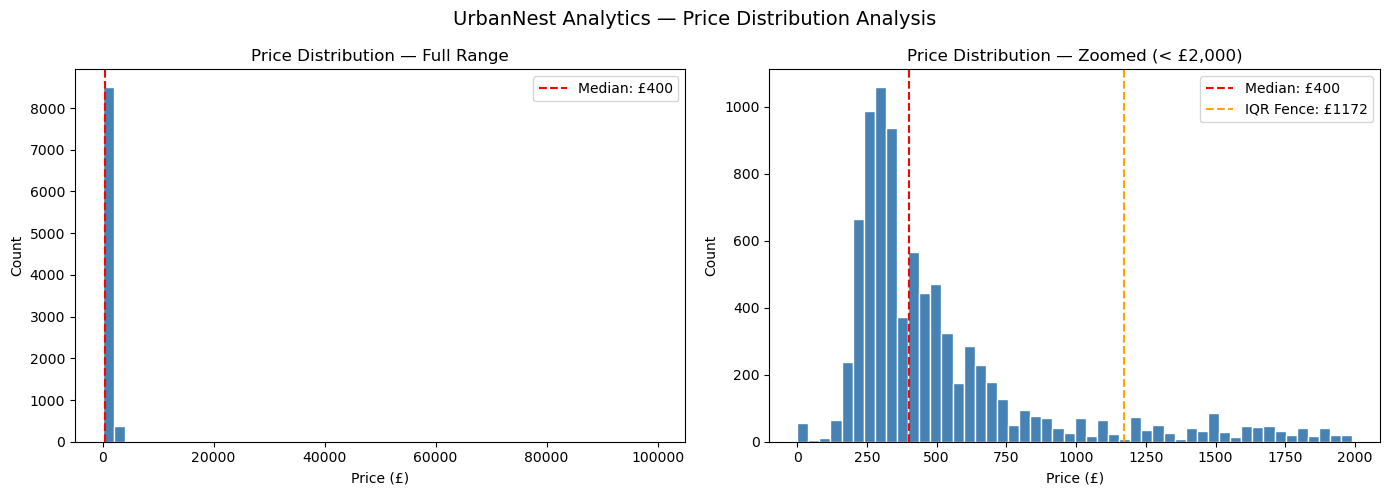

Chart saved ✅


In [45]:
# ============================================================
# Price distribution before outlier removal
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Full distribution
axes[0].hist(df['price'], bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution — Full Range')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['price'].median(),
                color='red', linestyle='--',
                label=f"Median: £{df['price'].median():.0f}")
axes[0].legend()

# Plot 2 — Zoomed (remove extreme outliers for viz)
df_viz = df[df['price'] < 2000]
axes[1].hist(df_viz['price'], bins=50,
             color='steelblue', edgecolor='white')
axes[1].set_title('Price Distribution — Zoomed (< £2,000)')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Count')
axes[1].axvline(df['price'].median(),
                color='red', linestyle='--',
                label=f"Median: £{df['price'].median():.0f}")
axes[1].axvline(upper_fence,
                color='orange', linestyle='--',
                label=f"IQR Fence: £{upper_fence:.0f}")
axes[1].legend()

plt.suptitle('UrbanNest Analytics — Price Distribution Analysis',
             fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/02_price_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

In [46]:
# ============================================================
# Flag price outliers
# ============================================================
df['is_price_outlier'] = (
    (df['price'] > upper_fence) |
    (df['price'] < 10)           # business logic floor
)

print(f"Normal listings:   {(~df['is_price_outlier']).sum():,}")
print(f"Outlier listings:  {df['is_price_outlier'].sum():,}")

# Remove extreme errors only
# Keep flagged outliers for reference
rows_before = len(df)
df = df[df['price'] >= 10].reset_index(drop=True)

print(f"\nRows after removing price < £10: {len(df):,}")
print(f"Removed: {rows_before - len(df)} rows")

Normal listings:   7,689
Outlier listings:  1,223

Rows after removing price < £10: 8,874
Removed: 38 rows


In [47]:
# ============================================================
# Fix total_size outliers
# Negative values → impossible → set to NaN
# Extreme values → unrealistic → set to NaN
# ============================================================
print(f"total_size before fix:")
print(f"  Negative values: {(df['total_size'] < 0).sum()}")
print(f"  > 1000 sqm:      {(df['total_size'] > 1000).sum()}")

# Set impossible values to NaN
df.loc[df['total_size'] < 0, 'total_size'] = np.nan
df.loc[df['total_size'] > 1000, 'total_size'] = np.nan

print(f"\ntotal_size after fix:")
print(f"  Min: {df['total_size'].min()}")
print(f"  Max: {df['total_size'].max()}")
print(f"  NaN: {df['total_size'].isnull().sum():,}")

total_size before fix:
  Negative values: 0
  > 1000 sqm:      18

total_size after fix:
  Min: 0.0
  Max: 800.0
  NaN: 4,675


## Step 7: Validate Cleaned Data

In [48]:
# Fix total_size = 0 — impossible value
df.loc[df['total_size'] == 0, 'total_size'] = np.nan
print(f"total_size min after fixing zeros: {df['total_size'].min()}")

total_size min after fixing zeros: 1.0


In [49]:
# ============================================================
# Final Data Validation
# ============================================================
print("=" * 50)
print("FINAL DATASET VALIDATION")
print("=" * 50)

print(f"\n✅ Total rows:     {len(df):,}")
print(f"✅ Total columns:  {df.shape[1]}")

print("\n--- Critical columns NULL check ---")
critical_cols = ['city', 'category', 'price', 'created_at']
for col in critical_cols:
    nulls = df[col].isnull().sum()
    status = "✅" if nulls == 0 else "⚠️"
    print(f"{status} {col}: {nulls} NULLs")

print("\n--- Price range check ---")
print(f"✅ Min price:    £{df['price'].min():.2f}")
print(f"✅ Max price:    £{df['price'].max():.2f}")
print(f"✅ Median price: £{df['price'].median():.2f}")

print("\n--- Boolean columns check ---")
bool_cols = ['furnished', 'washing_machine', 'tv',
             'balcony', 'garden', 'terrace',
             'registration_possible']
for col in bool_cols:
    unique_vals = df[col].dropna().unique().tolist()
    status = "✅" if all(v in ['yes','no'] for v in unique_vals) else "⚠️"
    print(f"{status} {col}: {unique_vals}")

print("\n--- Data types check ---")
print(df.dtypes)

print("\n--- Category distribution ---")
print(df['category'].value_counts())

print("\n--- City distribution (top 10) ---")
print(df['city'].value_counts().head(10))

FINAL DATASET VALIDATION

✅ Total rows:     8,874
✅ Total columns:  14

--- Critical columns NULL check ---
✅ city: 0 NULLs
✅ category: 0 NULLs
✅ price: 0 NULLs
✅ created_at: 0 NULLs

--- Price range check ---
✅ Min price:    £10.00
✅ Max price:    £100000.00
✅ Median price: £400.00

--- Boolean columns check ---
✅ furnished: ['yes', 'no']
✅ washing_machine: ['no', 'yes']
✅ tv: ['yes', 'no']
✅ balcony: ['no', 'yes']
✅ garden: ['no', 'yes']
✅ terrace: ['no', 'yes']
✅ registration_possible: ['yes', 'no']

--- Data types check ---
city                             object
category                         object
country_code                     object
created_at               datetime64[ns]
price                           float64
furnished                        object
total_size                      float64
registration_possible            object
washing_machine                  object
tv                               object
balcony                          object
garden                    

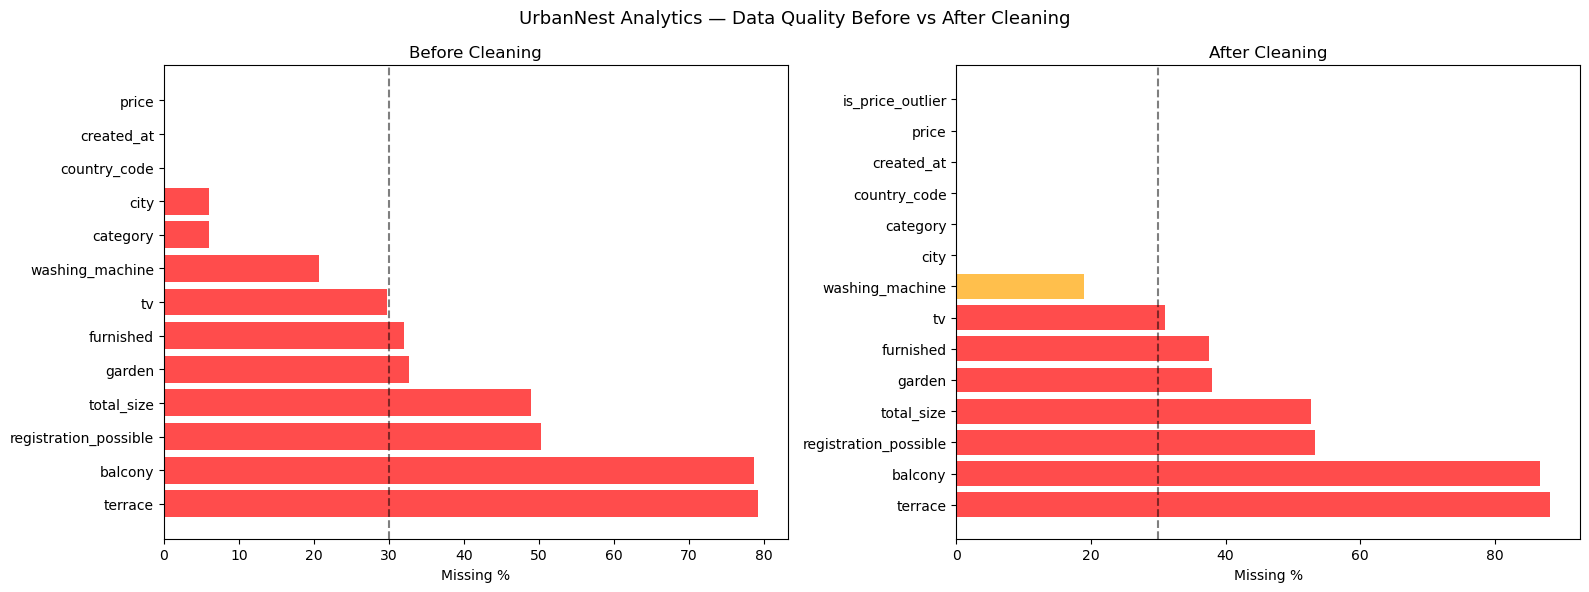

Chart saved ✅


In [50]:
# ============================================================
# Final NULL summary after all cleaning
# ============================================================
null_final = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct':   round(df.isnull().sum() * 100 / len(df), 2)
}).sort_values('null_pct', ascending=False)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before cleaning
profile_before = profile.set_index('column')['missing_pct']
axes[0].barh(profile_before.index,
             profile_before.values,
             color='red', alpha=0.7)
axes[0].set_title('Before Cleaning')
axes[0].set_xlabel('Missing %')
axes[0].axvline(x=30, color='black',
                linestyle='--', alpha=0.5)

# After cleaning
colors_after = ['red' if x > 30
                else 'orange' if x > 10
                else 'green'
                for x in null_final['null_pct']]
axes[1].barh(null_final.index,
             null_final['null_pct'],
             color=colors_after, alpha=0.7)
axes[1].set_title('After Cleaning')
axes[1].set_xlabel('Missing %')
axes[1].axvline(x=30, color='black',
                linestyle='--', alpha=0.5)

plt.suptitle('UrbanNest Analytics — Data Quality Before vs After Cleaning',
             fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/03_before_vs_after_cleaning.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

In [51]:
# ============================================================
# Export Clean Dataset
# ============================================================
df.to_csv('../data/ha_data_clean.csv', index=False)

print("✅ Clean dataset exported to data/ha_data_clean.csv")
print(f"   Shape: {df.shape}")
print(f"   Size:  {round(df.memory_usage().sum()/1024, 1)} KB")

✅ Clean dataset exported to data/ha_data_clean.csv
   Shape: (8874, 14)
   Size:  910.1 KB


In [52]:
# ============================================================
# Data Cleaning Summary
# ============================================================
print("=" * 55)
print("URBANNEST ANALYTICS — DATA CLEANING SUMMARY")
print("=" * 55)
print(f"Original rows:              10,000")
print(f"After dropping city/cat NULLs: {8916:,}")
print(f"After removing duplicates:     {8912:,}")
print(f"After removing price < £10:    {len(df):,}")
print(f"Total rows removed:            {10000 - len(df):,}")
print(f"Data retention rate:           {round(len(df)/10000*100, 1)}%")
print()
print("Fixes applied:")
print("  ✅ created_at → datetime64")
print("  ✅ total_size → float64")
print("  ✅ Triple quotes stripped from boolean columns")
print("  ✅ shared/private → yes in outdoor columns")
print("  ✅ null strings → NaN")
print("  ✅ Duplicate rows removed")
print("  ✅ Price < £10 removed (test/error listings)")
print("  ✅ total_size > 1000 sqm → NaN")
print("  ✅ total_size = 0 → NaN")
print("  ✅ is_price_outlier flag added")

URBANNEST ANALYTICS — DATA CLEANING SUMMARY
Original rows:              10,000
After dropping city/cat NULLs: 8,916
After removing duplicates:     8,912
After removing price < £10:    8,874
Total rows removed:            1,126
Data retention rate:           88.7%

Fixes applied:
  ✅ created_at → datetime64
  ✅ total_size → float64
  ✅ Triple quotes stripped from boolean columns
  ✅ shared/private → yes in outdoor columns
  ✅ null strings → NaN
  ✅ Duplicate rows removed
  ✅ Price < £10 removed (test/error listings)
  ✅ total_size > 1000 sqm → NaN
  ✅ total_size = 0 → NaN
  ✅ is_price_outlier flag added
